Color scale: 1.00 to 1068237.83


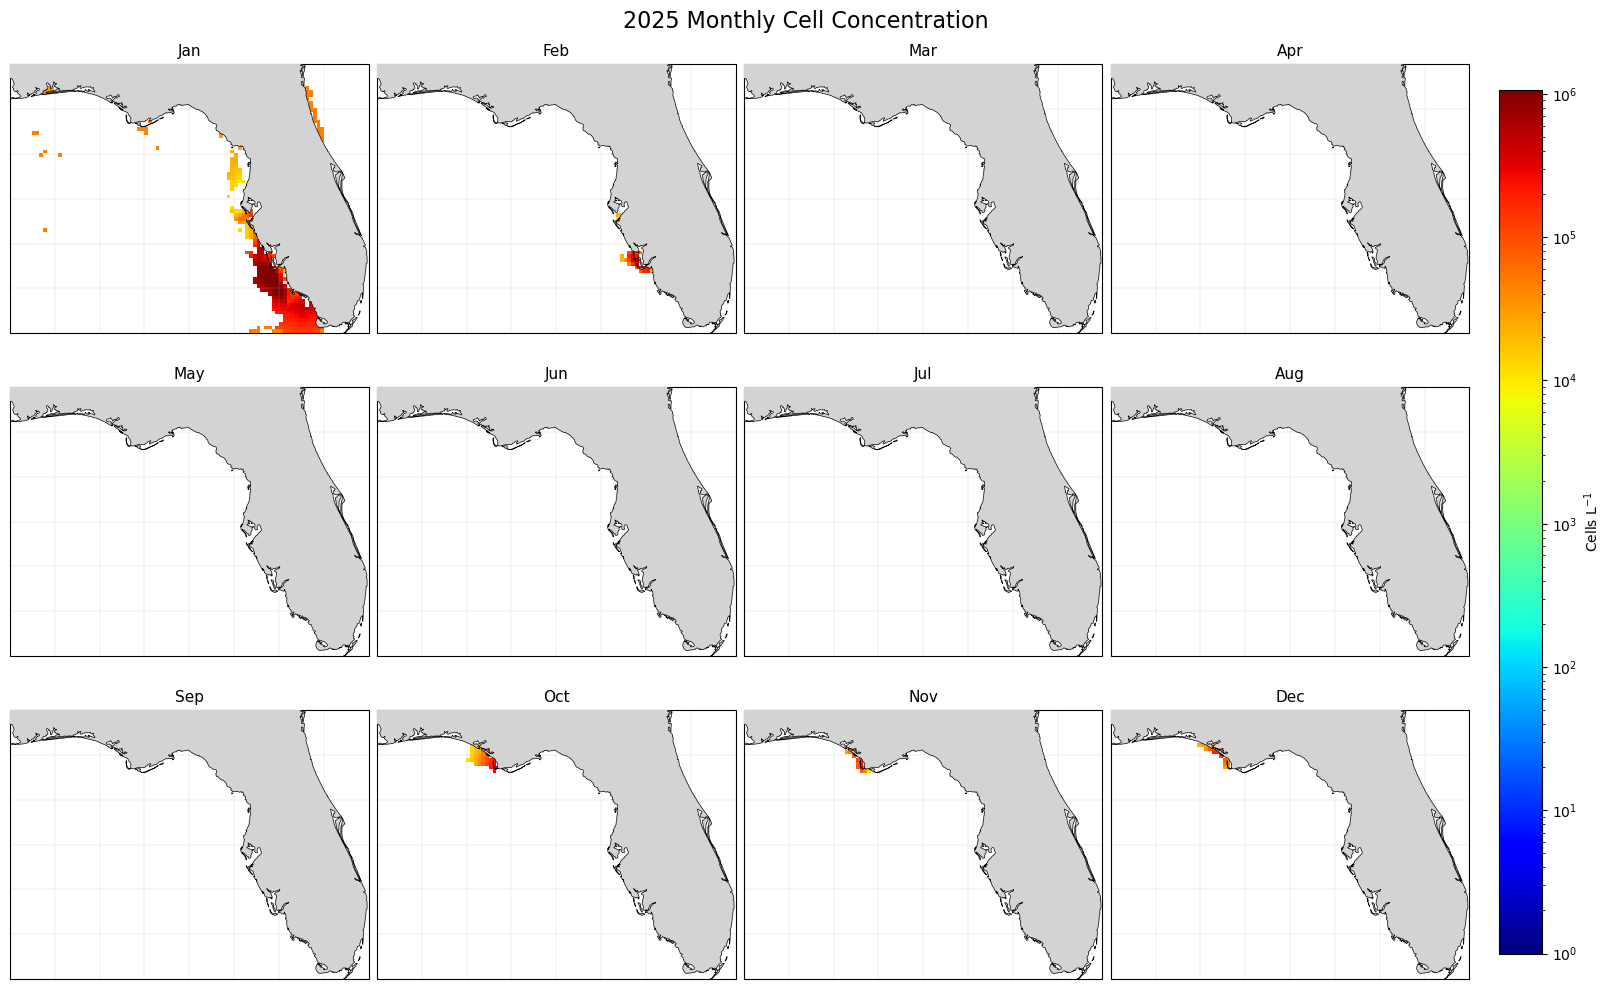

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data_dir = "/home/jovyan/Gulf-ESR/data/unformatted/ecospace_ascii"
year = 2025

# Florida bounding box
lon_min, lon_max = -88, -80
lat_min, lat_max = 25, 31

cmap = "jet"

# FUNCTION TO READ ASCII GRID

def read_asc(filepath):
    header = {}
    with open(filepath, "r") as f:
        header_lines = 0
        while header_lines < 6:
            line = f.readline()
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            key = parts[0].upper()
            value = parts[1]
            header[key] = float(value)
            header_lines += 1
        ncols = int(header["NCOLS"])
        nrows = int(header["NROWS"])
        xll = header["XLLCORNER"]
        yll = header["YLLCORNER"]
        cellsize = header["CELLSIZE"]
        nodata = header.get("NODATA_VALUE", -3.4e38)
        data = np.loadtxt(f)

    # Clean funky values
    data[data <= -1e20] = np.nan
    data[data == nodata] = np.nan
    data[data <= 0] = np.nan
    data[data < 10000] = np.nan 
    data = np.ma.masked_invalid(data)

    # Spatial extent
    extent = [xll, xll + ncols * cellsize, yll, yll + nrows * cellsize]
    return data, extent


# FIND FILES
pattern = os.path.join(data_dir, f"sdmTMB_log__{year}*.asc")
files = sorted(glob.glob(pattern))
monthly_files = {}
for f in files:
    basename = os.path.basename(f)
    datestr = basename.split("__")[1].split(".")[0]
    month = int(datestr[4:6])
    monthly_files[month] = f


# DETERMINE GLOBAL COLOR SCALE
all_valid = []
for month, f in monthly_files.items():
    data, extent = read_asc(f)
    valid = data.compressed()
    if len(valid) > 0:
        all_valid.append(valid)
if len(all_valid) == 0:
    raise ValueError("No valid data found.")
all_valid = np.concatenate(all_valid)

# Robust percentile scaling
vmin = 1 #np.nanpercentile(all_valid[all_valid > 0], 2)
vmax = np.nanpercentile(all_valid, 95)
print(f"Color scale: {vmin:.2f} to {vmax:.2f}")


# CREATE FIGURE
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(3, 4, figsize=(16, 10), subplot_kw={"projection": proj}, constrained_layout=True)
axes = axes.flatten()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
im = None

# PLOT EACH MONTH
for i in range(12):
    month = i + 1
    ax = axes[i]
    ax.set_title(month_names[i], fontsize=11)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
    if month in monthly_files:
        f = monthly_files[month]
        data, extent = read_asc(f)
        im = ax.imshow(data, extent=extent, origin="upper", cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax), interpolation="nearest", transform=proj, zorder=1)
    else:
        ax.text(0.5, 0.5, "No Data", ha="center", va="center", fontsize=12, transform=ax.transAxes)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)


if im is not None:
    cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.9, pad=0.02)
    cbar.set_label("Cells L$^{-1}$")

fig.suptitle(f"{year} Monthly Cell Concentration", fontsize=16)
output_file = f"{year}_monthly_cell_concentration.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()